# 02 - Data Cleaning & Missing Data Strategy

## Project

MaternalRisk: Early Prediction of Gestational Diabetes Using Explainable Machine Learning

**Author:** Kristen Cranford

**Date:** July 2026

---

## Objective

The goal of this notebook is to prepare the gestational diabetes dataset for exploratory analysis and predictive modeling.

Specifically, this notebook will:

- Investigate missing values
- Review feature data types
- Identify potential outliers
- Remove non-predictive variables
- Document preprocessing decisions
- Save a cleaned dataset for subsequent analyses

Rather than applying preprocessing automatically, each decision will be guided by data quality assessment and clinical context.

## Workflow

This notebook follows a structured analytical workflow:

1. Define the question.
2. Investigate the available evidence.
3. Interpret the findings.
4. Document any preprocessing or modeling decisions.
5. Summarize outcomes and identify next steps.

This approach emphasizes reproducibility and transparent decision-making throughout the project.

## Background

Raw clinical datasets often contain missing values, inconsistent data types, and variables that require careful consideration before modeling.

The objective of this notebook is to investigate data quality issues identified during the dataset audit, implement appropriate preprocessing steps, and document every decision made throughout the cleaning process.

## Investigation

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow

from pathlib import Path

In [23]:
DATA_PATH = Path("../data/raw/Gestational Diabetic Dat Set.xlsx")

df = pd.read_excel(DATA_PATH)

print(f"Dataset shape: {df.shape}")

Dataset shape: (3525, 17)


In [24]:
df.head()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
0,1,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,2,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,3,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,4,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,5,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


In [25]:
# Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3525
Columns: 17


In [26]:
# General information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No of Pregnancy                  3525 non-null   int64  
 3   Gestation in previous Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family History                   3525 non-null   int64  
 7   unexplained prenetal loss        3525 non-null   int64  
 8   Large Child or Birth Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys BP                           1820 non-null   float64
 11  Dia BP                           3525 non-null   int64  
 12  OGTT                           

## Recap of Dataset Audit

The dataset audit identified several issues requiring further investigation before modeling.

### Key findings

- Missing values were observed in several clinical variables.
- `Case Number` functions as a patient identifier rather than a predictor.
- OGTT measurements may introduce temporal leakage if the goal is early pregnancy prediction.
- Binary variables should be reviewed for appropriate data types.
- Potential outliers should be assessed before any preprocessing decisions are made.

The following sections investigate each of these issues in greater detail.

In [27]:
missing = (
    df.isna()
      .sum()
      .to_frame(name="Missing Values")
)

missing["Percent Missing"] = (
    missing["Missing Values"] / len(df) * 100
).round(2)

missing = missing.sort_values(
    by="Percent Missing",
    ascending=False
)

missing

,Missing Values,Percent Missing
Sys BP,1705,48.37
BMI,1081,30.67
HDL,1001,28.40
OGTT,513,14.55
Case Number,0,0.00
Gestation in previous Pregnancy,0,0.00
Family History,0,0.00
No of Pregnancy,0,0.00
Age,0,0.00
Large Child or Birth Default,0,0.00


### Interpretation

Missingness varies considerably across variables. While several features are complete, systolic blood pressure, BMI, HDL, and OGTT contain substantial proportions of missing observations and warrant further investigation before preprocessing decisions are made.

Before selecting an imputation strategy, it is important to determine whether the missingness occurs randomly or follows systematic patterns. Variables with substantial missingness may require different handling than those with only a few missing observations.

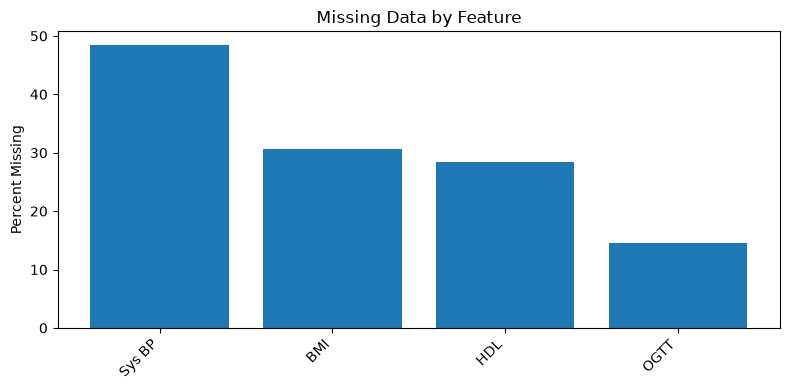

In [28]:
missing = missing[missing["Missing Values"] > 0]

plt.figure(figsize=(8,4))

plt.bar(
    missing.index,
    missing["Percent Missing"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Percent Missing")

plt.title("Missing Data by Feature")

plt.tight_layout()

plt.show()

In [29]:
df.groupby("Class Label(GDM /Non GDM)").apply(
    lambda x: x.isna().sum()
)

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes
Class Label(GDM /Non GDM),,,,,,,,,,,,,,,,
0,0,0,0,0,1081,52,0,0,0,0,1452,0,513,0,0,0
1,0,0,0,0,0,949,0,0,0,0,253,0,0,0,0,0


In [30]:
df.groupby("Class Label(GDM /Non GDM)")["BMI"].apply(
    lambda x: x.isna().mean()
)

Class Label(GDM /Non GDM)
0    0.50209
1    0.00000
Name: BMI, dtype: float64

In [31]:
df.groupby("Class Label(GDM /Non GDM)")["HDL"].apply(
    lambda x: x.isna().mean()
)

Class Label(GDM /Non GDM)
0    0.024152
1    0.691691
Name: HDL, dtype: float64

In [32]:
df.groupby("Class Label(GDM /Non GDM)")["Sys BP"].apply(
    lambda x: x.isna().mean()
)

Class Label(GDM /Non GDM)
0    0.674408
1    0.184402
Name: Sys BP, dtype: float64

In [33]:
df.groupby("Class Label(GDM /Non GDM)")["OGTT"].apply(
    lambda x: x.isna().mean()
)

Class Label(GDM /Non GDM)
0    0.238272
1    0.000000
Name: OGTT, dtype: float64

### Observation

The proportion of missing values differs substantially between the GDM and non-GDM groups for several clinical variables.

This suggests that missingness may not be completely random. Before selecting an imputation strategy, it is important to consider whether these patterns reflect differences in clinical practice, data collection procedures, or characteristics of the patient population.

In [34]:
class_counts = (
    df["Class Label(GDM /Non GDM)"]
      .value_counts()
      .sort_index()
)

class_percent = (
    df["Class Label(GDM /Non GDM)"]
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
      .round(2)
)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percent": class_percent
})

class_summary

,Count,Percent
Class Label(GDM /Non GDM),,
0,2153,61.08
1,1372,38.92


### Interpretation

The dataset contains 3,525 observations, with approximately 61% classified as non-GDM and 39% as GDM. Although the classes are not perfectly balanced, the imbalance is moderate and should be manageable using stratified sampling during model development.

The observed differences in missingness between the two outcome groups are unlikely to be explained solely by class proportions, suggesting that missing data patterns warrant further investigation before selecting an imputation strategy.

In [35]:
# Count missing values per patient
df["Missing Count"] = df.isna().sum(axis=1)

df["Missing Count"].value_counts().sort_index()

Missing Count
0     526
1    1698
2    1301
Name: count, dtype: int64

### Interpretation

Most patients contain one or two missing values, while only a small proportion of records are completely observed.

Importantly, no patient is missing more than two variables. This suggests that missingness is distributed across observations rather than concentrated in a small number of incomplete records. At this stage, there is no evidence that entire patient records should be excluded solely due to missing data.

In [36]:
missing_matrix = df.isna().astype(int)

missing_matrix.head()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM),Missing Count
0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0


In [37]:
missing_corr = missing_matrix.corr()

missing_corr

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM),Missing Count
Case Number,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No of Pregnancy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gestation in previous Pregnancy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMI,NaN,NaN,NaN,NaN,1.000000,-0.418827,NaN,NaN,NaN,NaN,-0.049080,NaN,0.620539,NaN,NaN,NaN,NaN,NaN
HDL,NaN,NaN,NaN,NaN,-0.418827,1.000000,NaN,NaN,NaN,NaN,-0.225563,NaN,-0.259898,NaN,NaN,NaN,NaN,NaN
Family History,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
unexplained prenetal loss,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Large Child or Birth Default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


| Variables     | Missingness Correlation |
| ------------- | ----------------------: |
| BMI ↔ OGTT    |                **0.62** |
| BMI ↔ HDL     |               **-0.42** |
| Sys BP ↔ OGTT |               **-0.40** |
| HDL ↔ Sys BP  |               **-0.23** |

BMI and OGTT missingness correlate at 0.62. That suggests patients missing BMI are also often missing OGTT.

### Interpretation

Correlations among the missingness indicators were calculated to explore whether variables tend to be absent together.

Only variables containing missing observations produced meaningful correlations, as features with no missing values have no variation in their missingness indicators.

A moderate positive correlation was observed between BMI and OGTT missingness, suggesting these variables are sometimes missing in the same patients. Overall, however, the analysis provides limited evidence regarding the underlying mechanism of missingness.

Combined with the earlier finding that missingness differs between the GDM and non-GDM groups, the results suggest that the data are unlikely to be Missing Completely at Random (MCAR). This should be considered when selecting preprocessing strategies later in the project.


## Decision Point 1: Record Removal

**Question**

Should patient records be removed due to missing data?

**Evidence**

526 patients have complete data.
1,698 patients are missing one value.
1,301 patients are missing two values.
No patient is missing more than two values.

**Decision**

No records will be removed at this stage.

**Rationale**

Although missingness is common, it is limited to one or two variables per patient. There is insufficient evidence to justify excluding observations based solely on missing data.

## Decision Point 2 — Remove Case Number

**Question**

Should Case Number be retained as a predictor?

**Evidence**

Each value is unique.
The variable serves as a patient identifier.
It contains no clinical information.
Including it could introduce noise into predictive models.

**Decision**

Remove Case Number from the modeling dataset.

**Rationale**

Patient identifiers do not contribute meaningful predictive information and should not be used as features in machine learning models.

## Question

Are the variables stored using appropriate data types?

In [38]:
df.dtypes

Case Number                          int64
Age                                  int64
No of Pregnancy                      int64
Gestation in previous Pregnancy      int64
BMI                                float64
HDL                                float64
Family History                       int64
unexplained prenetal loss            int64
Large Child or Birth Default         int64
PCOS                                 int64
Sys BP                             float64
Dia BP                               int64
OGTT                               float64
Hemoglobin                         float64
Sedentary Lifestyle                  int64
Prediabetes                          int64
Class Label(GDM /Non GDM)            int64
Missing Count                        int64
dtype: object

## Interpretation

All variables were imported using appropriate numeric data types. Binary indicators are represented as 0/1 integers, which are suitable for downstream machine learning models. No data type conversions are required at this stage.

## Decision Point 3 — Data Types

**Decision**

No data type conversions are required at this stage.

**Rationale**

All variables were imported using appropriate numeric data types. Binary indicators represented as 0/1 integers are suitable for downstream machine learning models.

In [39]:
df = df.drop(columns=["Case Number"])

## Decision Point — Remove Identifier

**Decision**

Remove `Case Number`.

**Rationale**

The variable functions solely as a patient identifier and does not contain clinically meaningful information for prediction.

Question

Do any continuous variables contain implausible values?

## Investigation

The following analyses investigate the data quality issues identified during the dataset audit. Each section addresses a specific question, interprets the evidence, and documents any resulting preprocessing decisions.

In [40]:
continuous_cols = [
    "Age",
    "BMI",
    "HDL",
    "Sys BP",
    "Dia BP",
    "Hemoglobin"
]

df[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,3525.0,32.581277,6.169107,20.0,28.0,32.0,37.0,45.0
BMI,2444.0,27.854092,5.714737,13.3,24.4,27.5,31.0,45.0
HDL,2524.0,46.471870,10.800813,15.0,42.0,49.0,55.0,70.0
Sys BP,1820.0,135.762088,22.742844,90.0,122.0,132.0,153.0,185.0
Dia BP,3525.0,81.538156,11.379758,60.0,74.0,81.0,86.0,124.0
Hemoglobin,3525.0,13.959801,1.863969,8.8,12.7,14.0,15.0,18.0


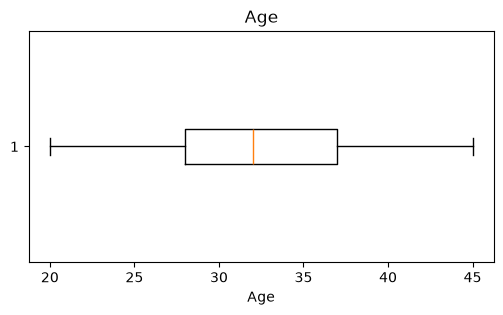

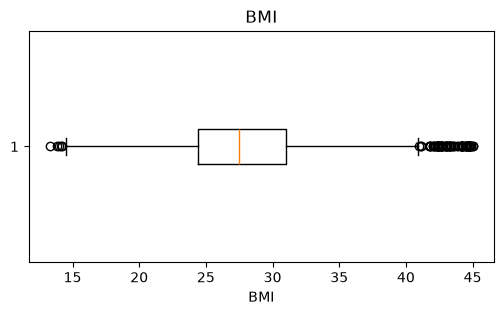

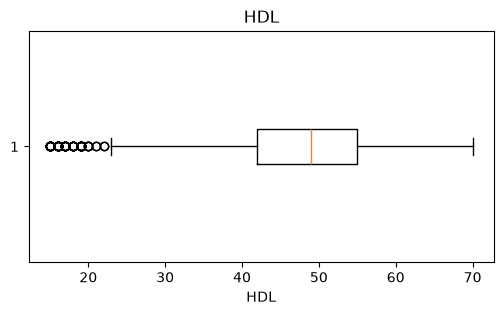

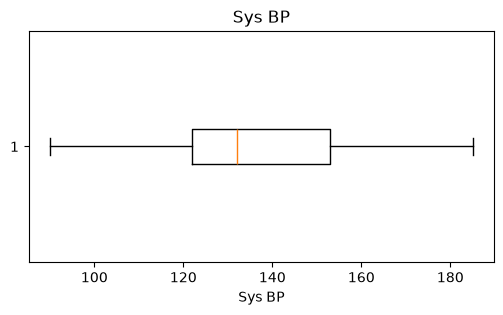

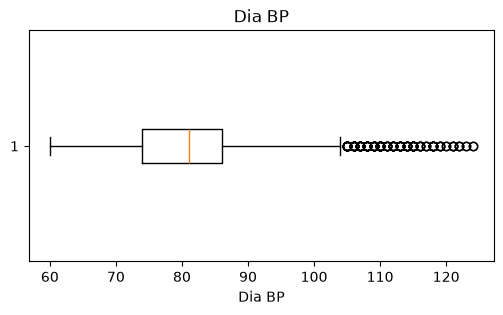

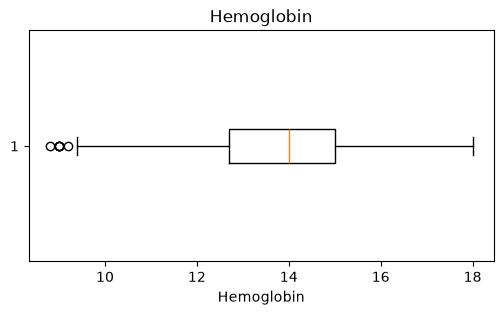

In [41]:
for col in continuous_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col].dropna(), orientation="horizontal")
    plt.title(col)
    plt.xlabel(col)
    plt.show()

## Interpretation

Summary statistics and box plots were reviewed for all continuous clinical variables.

Several variables contain observations that would be considered statistical outliers. However, none of the observed values appear physiologically impossible or strongly suggest data entry errors.

Given the clinical context, these observations are more appropriately interpreted as genuine variation within the patient population rather than erroneous measurements.

## Decision Point — Outlier Handling

**Question**

Should observations be removed based on extreme values?

**Evidence**

Continuous variables contain several extreme observations, but all values fall within clinically plausible ranges.

**Decision**

No observations will be removed based on outlier assessment.

**Rationale**

Extreme clinical measurements may represent genuine patient conditions rather than recording errors. Removing these observations could reduce the clinical validity of the dataset and potentially bias downstream analyses.

### Final Preprocessing Actions

The following changes have been applied to the dataset:

- Removed `Case Number`.
- Retained all patient records.
- Deferred missing-value imputation.
- Retained clinically plausible extreme observations.
- Preserved existing data types.

The cleaned dataset will now be saved for use in subsequent analyses.

In [42]:
OUTPUT_PATH = Path("../data/processed/gdm_clean.parquet")

df.to_parquet(OUTPUT_PATH, index=False)

print(f"Cleaned dataset saved to: {OUTPUT_PATH}")

Cleaned dataset saved to: ..\data\processed\gdm_clean.parquet


## Summary

This notebook investigated the quality of the gestational diabetes dataset and documented the preprocessing strategy.

Key outcomes included:

- Missing data patterns were characterized.
- Record completeness was assessed.
- Non-predictive variables were identified.
- Preprocessing decisions were documented and justified.

The cleaned dataset produced here will serve as the foundation for exploratory data analysis in the next notebook.

## Next Steps

The next notebook will explore the cleaned dataset by examining feature distributions, relationships with the target variable, and clinically relevant patterns that may inform predictive modeling.